In [11]:
import pandas as pd
from Bio import SeqIO

In [12]:
def parse_fasta_to_dataframe(fasta_file):
    """
    Parse a FASTA file and create a pandas DataFrame with PDB_ID, length, and sequence.
    
    Parameters:
    fasta_file (str): Path to the FASTA file
    
    Returns:
    pandas.DataFrame: DataFrame containing PDB_ID, length, and sequence
    """
    data = []
    for record in SeqIO.parse(fasta_file, "fasta"):
        pdb_id = record.id.split('_')[1]  # Assuming PDB_ID is part of the record ID
        seq = record.seq
        length = len(record.seq)
        data.append({'PDB_ID': pdb_id, 'length': length, 'seq': seq})
    
    return pd.DataFrame(data)

def write_fasta_from_dataframe(df, output_file):
    """
    Write a FASTA file from a DataFrame with 'PDB_ID' and 'sequence' columns.
    
    Parameters:
    df (pandas.DataFrame): DataFrame containing 'PDB_ID' and 'sequence' columns
    output_file (str): Path to the output FASTA file
    """
    with open(output_file, 'w') as f:
        for _, row in df.iterrows():
            # Write header line (starting with '>')
            f.write(f">{row['PDB_ID']}\n")
            # Write sequence line
            f.write(f"{row['seq']}\n")

## Prepare Blast

In [13]:
# Example usage
fasta_file = './denovo.fasta'
df = parse_fasta_to_dataframe(fasta_file)

In [14]:
predictions = pd.read_csv('../pda_predictions.csv',names=['PDB_ID','Probability'])
predictions['PDB_ID'] = predictions['PDB_ID'].str.split('_').str[1]

# Add sequence information to the predictions
predictions_merged = pd.merge(predictions,df,on='PDB_ID')

# Filter for sequences with length >= 50 and probability < 0.5
pred_data = predictions_merged[(predictions_merged['length'] >= 50) & (predictions_merged['Probability'].astype(float) < 0.5)].copy()

# generate fasta file for blast
write_fasta_from_dataframe(pred_data, "./blast.fasta")

## Analyse Blast

In [15]:
blast_data = pd.read_csv('./XJHY97M7013-Alignment-HitTable.csv',names=['PDB_ID','Hit','Identity','Length','Mismatches','Gaps','Qstart','Qend','Hstart','Hend','Evalue','BitScore','whatever'])
data_merged = pd.merge(pred_data,blast_data,on='PDB_ID')


# Filter for sequences with length >= 50, probability < 0.5, and identity < 100
filtered_data = data_merged[(data_merged['length'] > 50) & (data_merged['Probability'].astype(float) < 0.5) & (data_merged['Identity'] < 100.0)]

to_investigate = data_merged[~data_merged['PDB_ID'].isin(filtered_data['PDB_ID'])]

In [16]:
info = pd.read_csv('./pda_exported_designs.csv')
df = pd.merge(to_investigate, info, left_on='PDB_ID', right_on='pdb_code')


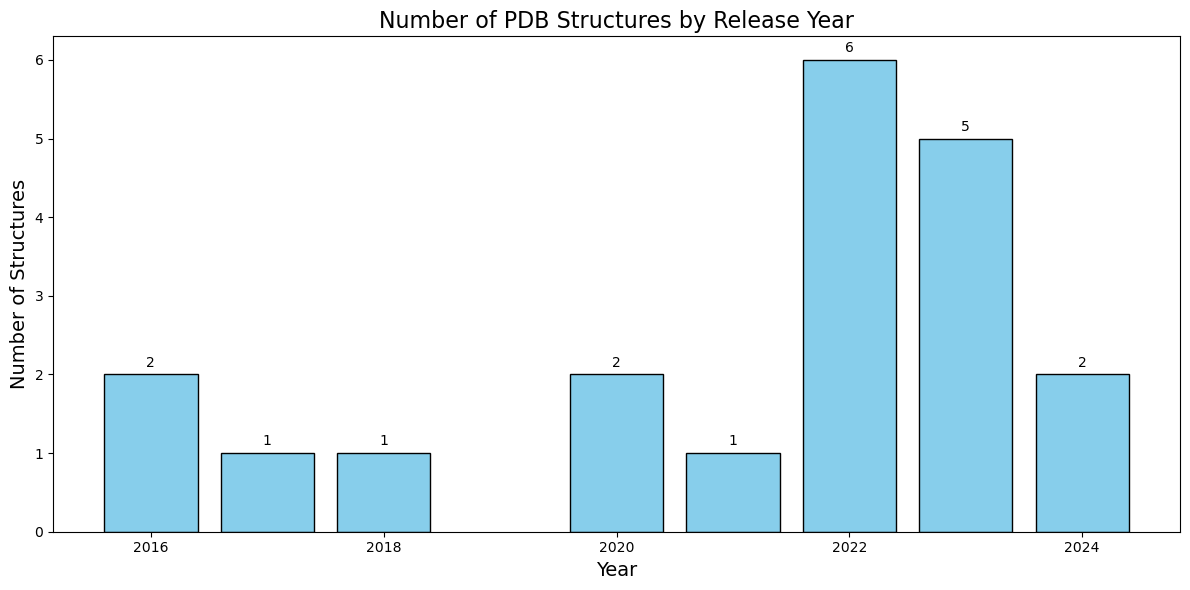

<Figure size 640x480 with 0 Axes>

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract year from release_date column
df['year'] = pd.to_datetime(df['release_date']).dt.year

# Count structures by year
year_counts = df['year'].value_counts().sort_index()

# Create the bar plot
plt.figure(figsize=(12, 6))
bars = plt.bar(year_counts.index, year_counts.values, color='skyblue', edgecolor='black')

# Add labels and title
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Structures', fontsize=14)
plt.title('Number of PDB Structures by Release Year', fontsize=16)

# Add count labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.0f}', ha='center', fontsize=10)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

# Save the plot
plt.savefig('pdb_structures_by_release_year.png', dpi=300, bbox_inches='tight')